In [2]:
import pandas as pd
import datetime
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams
plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = r'\usepackage{lmodern}'  # Usar Latin Modern Roman
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Latin Modern Roman']
import numpy as np
from tensorflow import keras
#sns.set_style('dark')
plt.rcParams['font.size'] = 16
import json
import os
import copy
from IPython.display import display, HTML

# from sklearn.metrics import mean_squared_error
# from sklearn.metrics import r2_score

import scipy as sp
from scipy.optimize import curve_fit

import uproot
import awkward as ak

import awkward as ak
import matplotlib.pyplot as plt
import hist
import math
import numpy as np
import vector
import pylhe
import seaborn as sns
from matplotlib import colormaps

# Signal events for 1l

## Read in the signal

In [3]:
fileg = "../MadGraph/ppWWjj1l/Events/run_01/unweighted_events.lhe"
events = pylhe.to_awkward(pylhe.read_lhe_with_attributes(fileg))

Identify the particles

In [4]:
j1=events.particles.vector[:,-2]
j2=events.particles.vector[:,-1]
Wp=events.particles.vector[:,3]
Wm=events.particles.vector[:,2]
lp=events.particles.vector[:,-6]
lm=events.particles.vector[:,-4]
nup=events.particles.vector[:,-5]
num=events.particles.vector[:,-3]

In [23]:
mWW = (Wp+Wm).mass

Function to read in the total cross section and total number of events from the lhe file. Note that for different processes the rows may shift.

In [5]:
def read_sigma_nevents(filename):
    with open(filename,'r') as f:
        data = f.readlines()
    f.close()
    sigma = float(data[439].split(' ')[13])
    nevents = float(data[151].split(' ')[2])
    return sigma, nevents

In [6]:
(sigma, Ntot) = read_sigma_nevents(fileg)

In [7]:
sigma

0.0016999165897033542

In [8]:
Ntot

100000.0

## Data Visualisation!

delta R separation between the lepton and neutrino pairs.
Maybe we have to generate again and use differerent Delta R for the two pairs (one is for jets, one for 1l)? 
But this cut does not exist in the run card, so probably we can not define any angle with MET. Then it doesn't matter which W to take for what.

In [9]:
min(lp.deltaR(nup))

0.043360814876566824

In [13]:
max(lp.deltaR(nup))

5.978748463513672

In [14]:
min(lm.deltaR(num))

0.05480353327103716

In [15]:
max(lm.deltaR(num))

6.738088891453228

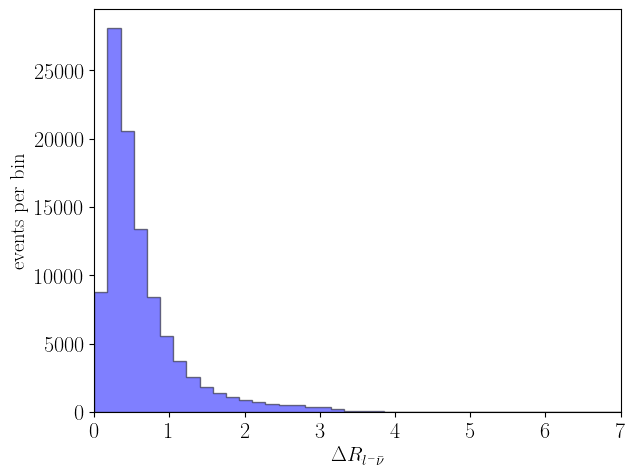

In [19]:
# histogram for NP signal (n = number of events per bin)
# density=True gives bin's raw count divided by the total number of counts and the bin width, i.e. density = counts / (sum(counts) * np.diff(bins)
n_dR, bins_dR, _ =plt.hist(lm.deltaR(num),bins=40,range=(0,7),label='non-linear axion', alpha=0.5,density=False,color = "blue", ec="k",histtype='stepfilled',log=False)
plt.xlim(0, 7)
plt.tight_layout()
plt.xlabel(r'$\Delta R_{l^-\bar{\nu}}$ ',fontsize=15)
plt.ylabel(r'events per bin',fontsize=15)
#plt.savefig("mgammagamma.pdf")
plt.show()

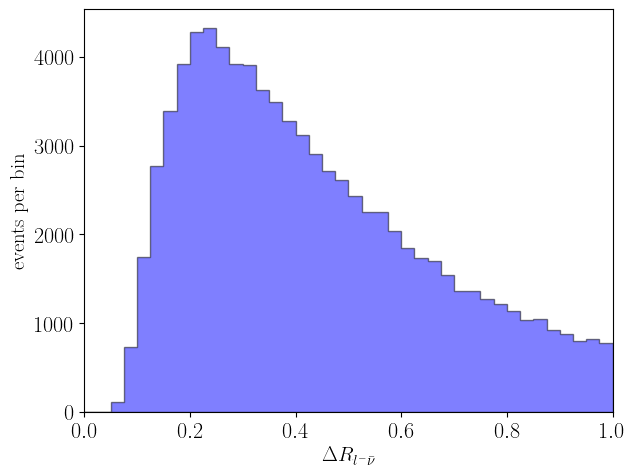

In [20]:
# histogram for NP signal (n = number of events per bin)
# density=True gives bin's raw count divided by the total number of counts and the bin width, i.e. density = counts / (sum(counts) * np.diff(bins)
n_dR, bins_dR, _ =plt.hist(lm.deltaR(num),bins=40,range=(0,1),label='non-linear axion', alpha=0.5,density=False,color = "blue", ec="k",histtype='stepfilled',log=False)
plt.xlim(0, 1)
plt.tight_layout()
plt.xlabel(r'$\Delta R_{l^-\bar{\nu}}$ ',fontsize=15)
plt.ylabel(r'events per bin',fontsize=15)
#plt.savefig("mgammagamma.pdf")
plt.show()

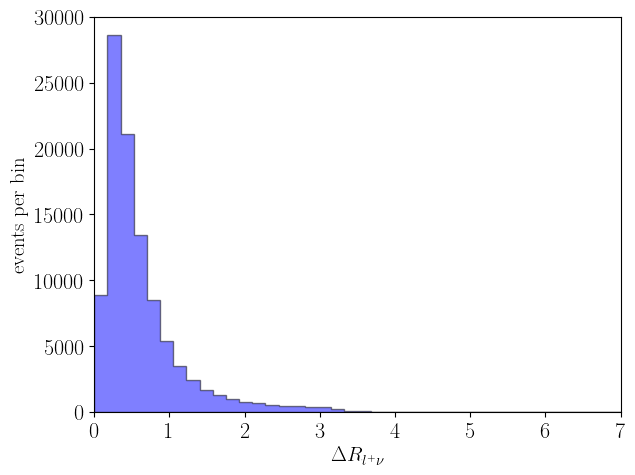

In [21]:
# histogram for NP signal (n = number of events per bin)
# density=True gives bin's raw count divided by the total number of counts and the bin width, i.e. density = counts / (sum(counts) * np.diff(bins)
n_dR, bins_dR, _ =plt.hist(lp.deltaR(nup),bins=40,range=(0,7),label='non-linear axion', alpha=0.5,density=False,color = "blue", ec="k",histtype='stepfilled',log=False)
plt.xlim(0, 7)
plt.tight_layout()
plt.xlabel(r'$\Delta R_{l^+\nu}$ ',fontsize=15)
plt.ylabel(r'events per bin',fontsize=15)
#plt.savefig("mgammagamma.pdf")
plt.show()

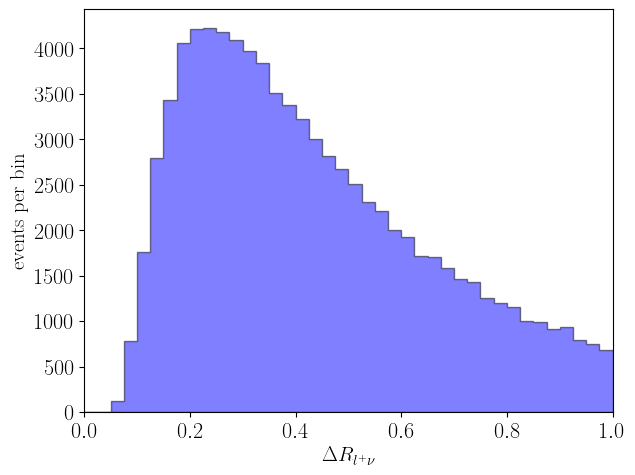

In [22]:
# histogram for NP signal (n = number of events per bin)
# density=True gives bin's raw count divided by the total number of counts and the bin width, i.e. density = counts / (sum(counts) * np.diff(bins)
n_dR, bins_dR, _ =plt.hist(lp.deltaR(nup),bins=40,range=(0,1),label='non-linear axion', alpha=0.5,density=False,color = "blue", ec="k",histtype='stepfilled',log=False)
plt.xlim(0, 1)
plt.tight_layout()
plt.xlabel(r'$\Delta R_{l^+\nu}$ ',fontsize=15)
plt.ylabel(r'events per bin',fontsize=15)
#plt.savefig("mgammagamma.pdf")
plt.show()

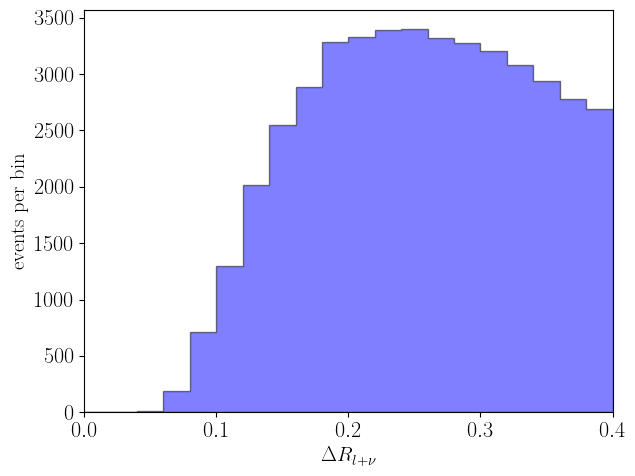

In [24]:
n_J, bins_J, _ =plt.hist(lp.deltaR(nup),bins=20,range=(0,0.4),label='non-linear axion', alpha=0.5,density=False,color = "blue", ec="k",histtype='stepfilled',log=False)
plt.xlim(0, 0.4)
plt.tight_layout()
plt.xlabel(r'$\Delta R_{l+ \nu}$ ',fontsize=15)
plt.ylabel(r'events per bin',fontsize=15)
#plt.savefig("mgammagamma.pdf")
plt.show()

In [25]:
# fraction of the events that results in the fat jet topology
n_J.sum()/Ntot

0.44352

We define that the $W^+$ decays hadronically into two resolved jets or one fat jet. Focus on the resolved region with $\Delta R_{\nu\nu} > 0.4$ first

In [27]:
# resolved
mWW_res = [mWW[i] for i in range(len(events)) if (lp.deltaR(nup))[i] > 0.4];

In [61]:
# fat jet region
mWW_fat = [mWW[i] for i in range(len(events)) if (lp.deltaR(nup))[i] < 0.4];

# Invariant mass of the WW $m_{l \nu jj}$ in the resolved region

In [103]:
mWW_bins = (0,200,400,600,800,1000,1200,1400,1600,1800,2000);

In [104]:
mWW_bin_center = (100,300,500,700,900,1100,1300,1500,1700,1900);

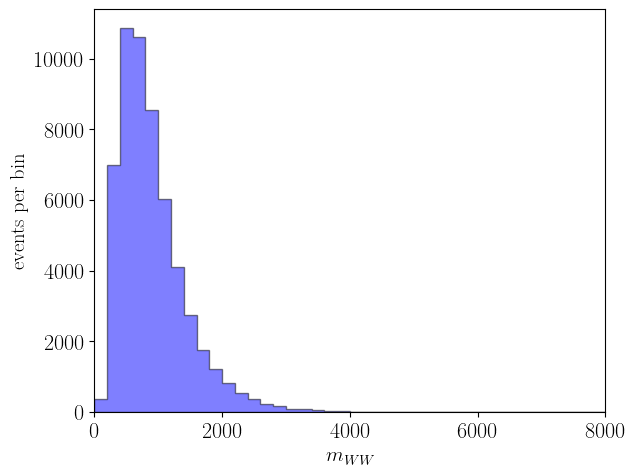

In [105]:
# in arbitrary bins
n, bins, _ =plt.hist(mWW_res,bins=40,range=(0,8000),label='non-linear axion', alpha=0.5,density=False,color = "blue", ec="k",histtype='stepfilled',log=False)
plt.xlim(0, 8000)
plt.tight_layout()
plt.xlabel(r'$m_{WW}$ ',fontsize=15)
plt.ylabel(r'events per bin',fontsize=15)
#plt.savefig("mgammagamma.pdf")
plt.show()

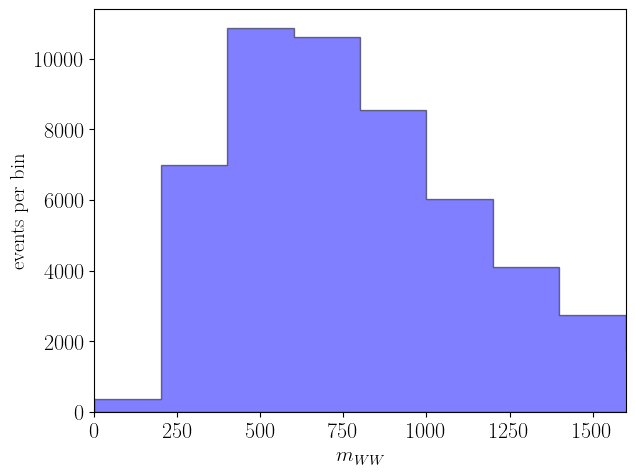

In [106]:
# in ATLAS bins
n, bins, _ =plt.hist(mWW_res,bins=mWW_bins,range=(0,1600),label='non-linear axion', alpha=0.5,density=False,color = "blue", ec="k",histtype='stepfilled',log=False)
plt.xlim(0, 1600)
plt.tight_layout()
plt.xlabel(r'$m_{WW}$ ',fontsize=15)
plt.ylabel(r'events per bin',fontsize=15)
#plt.savefig("mgammagamma.pdf")
plt.show()

In [107]:
# calculate the efficiency as the number of events that fall into the bins
eps = n.sum()/Ntot

## Read in the digitised data and background from Figure 10d in the auxiliary material


In [108]:
#background 
background = pd.read_csv('../MadGraph/ppWWjj1l/1leptonBG.csv', sep=';', nrows=10, header=0).values[:,1]

In [109]:
data_by_BG = pd.read_csv('../MadGraph/ppWWjj1l/1leptonData_BG_point.csv', sep=';', nrows=10, header=0).values[:,1]

In [110]:
unc_upper_by_BG = pd.read_csv('../MadGraph/ppWWjj1l/1leptonData_BG_upper.csv', sep=';', nrows=10, header=0).values[:,1]

In [111]:
unc_lower_by_BG = pd.read_csv('../MadGraph/ppWWjj1l/1leptonData_BG_lower.csv', sep=';', nrows=10, header=0).values[:,1]

In [112]:
data = np.multiply(data_by_BG, background)
unc_upper = np.multiply(unc_upper_by_BG, background)
unc_lower = np.multiply(unc_lower_by_BG, background)

In [113]:
data

array([ 2005.84253166, 40756.95640909, 18718.0176149 ,  6069.04930469,
        2270.05241854,   872.20216037,   365.77828448,   186.3893336 ,
         105.88563596,    49.13192977])

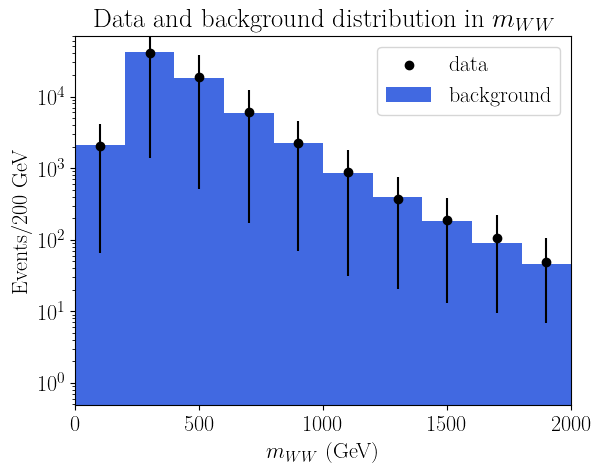

In [114]:
plt.bar(mWW_bins[:-1], background, width=np.diff(mWW_bins), align='edge', alpha=1, color='royalblue',label='background')
plt.scatter(mWW_bin_center, data, color='black', label='data')
plt.xlim(0,2000)
#plt.ylim(0,5)
plt.yscale("log")
plt.errorbar(mWW_bin_center, data, [unc_lower, unc_upper], color='black', alpha=1,fmt='none')
plt.xlabel('$m_{WW}$ (GeV) ')
plt.ylabel(r'Events/200 GeV')
plt.title("Data and background distribution in $m_{WW}$")
plt.legend()

In [115]:
(data*np.diff(mWW_bins)).sum()

14279861.124612313

## Signal events in the right bins, normalised distribution 

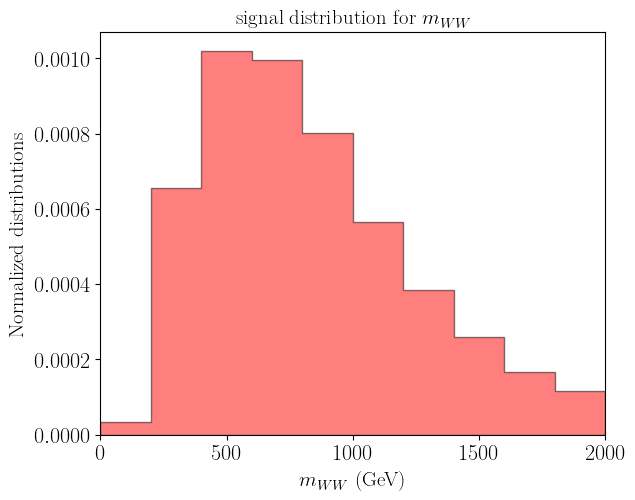

In [116]:
# histogram for NP signal (n = number of events per bin)
# density=True gives bin's raw count divided by the total number of counts and the bin width, i.e. density = counts / (sum(counts) * np.diff(bins))
n_signal, bins, _ = plt.hist(mWW_res,bins=mWW_bins,range=(0,2000),label='non-linear axion', alpha=0.5,density=True,color = "red", ec="k",histtype='stepfilled',log=False)
plt.xlim(0, 2000)
#plt.yscale("log")
plt.tight_layout()
plt.title(r'signal distribution for $m_{WW}$ ',fontsize=15)
plt.xlabel(r'$m_{WW}$ (GeV)',fontsize=15)
plt.ylabel(r'Normalized distributions',fontsize=15)
#plt.savefig("mHHdist.pdf")
plt.show()

In [117]:
(n_signal*np.diff(mWW_bins)).sum()

1.0

## Compare signal with data and background


In [118]:
# BR: factor of the branching ratios due to generating Z-> nu nu instead of Z-> jj
BR_Wlnu = 0.326
BR_Wjj = 0.6732

BR = BR_Wjj/BR_Wlnu

In [119]:
# rescale the MG5 signal events to compare with the data: N_events = n_signal * lumi * sigma * eps * BR
# eps = efficiency to the bin selection = number of events that fall in the ATLAS bins/ number of all events
# sigma in lhe file: total cross section including BR sigma in pb


# careful! the lumi is given in fb^-1 but the cross section from MadGraphin pb, which explains the additional factor of 1000.
lumi = 140

N_events = n_signal*lumi*sigma*1000*eps*BR

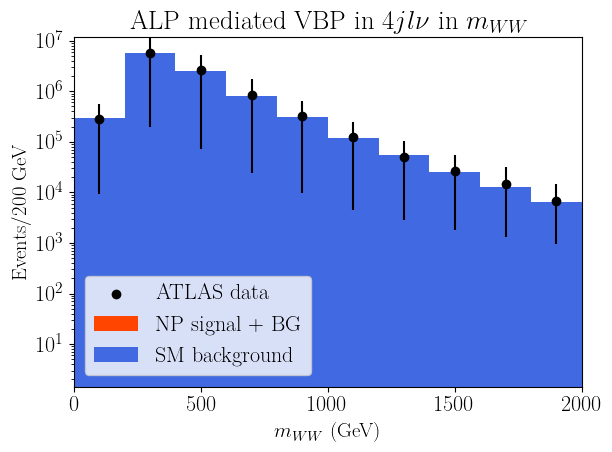

In [120]:
plt.bar(mWW_bins[:-1], background*lumi+N_events, width=np.diff(mWW_bins), align='edge', alpha=1, color='orangered', label='NP signal + BG')
plt.bar(mWW_bins[:-1], background*lumi, width=np.diff(bins), align='edge', alpha=1, color='royalblue',label='SM background')
plt.xlim(0, 2000)
#plt.ylim(0,10000)
plt.yscale("log")
plt.xlabel('$m_{WW}$ (GeV)',fontsize=15)
plt.ylabel(r'Events/200 GeV', fontsize=15)
plt.errorbar(mWW_bin_center, data*lumi, yerr=[unc_lower*lumi, unc_upper*lumi], color='black', alpha=1,fmt='none')
plt.scatter(mWW_bin_center, data*lumi, color='black', label='ATLAS data')
plt.legend(loc=3)
plt.title(r" ALP mediated VBP in $4jl\nu$ in $m_{WW}$")
plt.tight_layout()
plt.savefig("/Users/esser/Documents/PROJECTS/ALPsPheno/ALP GLOBAL/github/ALP_GLOBAL/Figures/WWjj1l_res.pdf")
plt.show()

### Output data to Mathematica

In [55]:
# calculate the mean error from the upper and lower end
data_unc = (unc_upper-unc_lower)/2

In [56]:
# data
Mathematica_data = "{" + ",".join([f"{x:.4e}".replace('e', '*10^') for x in data]) + "}" + ";"
print(Mathematica_data)

{2.0058*10^+03,4.0757*10^+04,1.8718*10^+04,6.0690*10^+03,2.2701*10^+03,8.7220*10^+02,3.6578*10^+02,1.8639*10^+02,1.0589*10^+02,4.9132*10^+01};


In [57]:
# data unc
Mathematica_data_unc = "{" + ",".join([f"{x:.4e}".replace('e', '*10^') for x in data_unc]) + "}" ";"
print(Mathematica_data_unc)

{6.2635*10^+01,1.2485*10^+03,5.3402*10^+02,1.7310*10^+02,7.2500*10^+01,3.0063*10^+01,1.9409*10^+01,1.3397*10^+01,1.0103*10^+01,7.5241*10^+00};


In [58]:
# background
Mathematica_background = "{" + ",".join([f"{x:.4e}".replace('e', '*10^') for x in background]) + "}" ";"
print(Mathematica_background)

{2.1140*10^+03,4.1369*10^+04,1.8144*10^+04,5.8014*10^+03,2.2193*10^+03,8.4806*10^+02,3.9829*10^+02,1.8400*10^+02,9.1114*10^+01,4.6058*10^+01};


In [59]:
# signal
N_signal = n_signal * lumi * sigma * 1000 * eps * BR
Mathematica_signal = "{" + ",".join([f"{x:.4e}".replace('e', '*10^') for x in N_signal]) + "}" ";"
print(Mathematica_signal)

{8.8953*10^-03,1.7154*10^-01,2.6669*10^-01,2.6045*10^-01,2.0970*10^-01,1.4790*10^-01,1.0072*10^-01,6.7821*10^-02,4.3494*10^-02,3.0249*10^-02};


In [60]:
# bin center
Mathematica_bin_center = "{" + ",".join(["{:.0f}".format(x) for x in mWW_bin_center]) + "}" ";"
print(Mathematica_bin_center)

{100,300,500,700,900,1100,1300,1500,1700,1900};


# Invariant mass of the WW $m_{l \nu J}$ in the merged region

In [121]:
mWW_bins = (0,200,400,600,800,1000,1200,1400,1600,1800,2000);

In [122]:
mWW_bin_center = (100,300,500,700,900,1100,1300,1500,1700,1900);

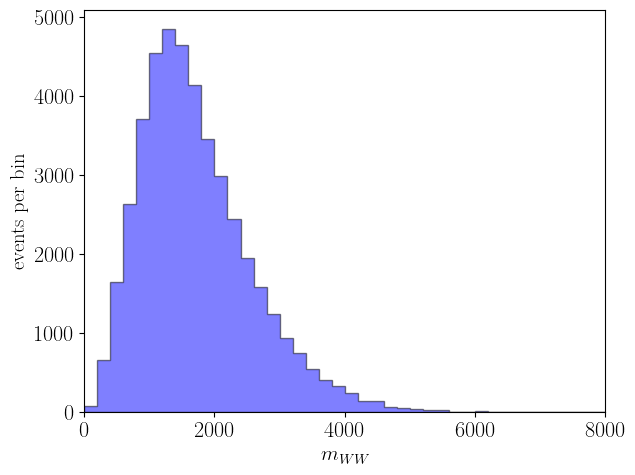

In [123]:
# in arbitrary bins
n, bins, _ =plt.hist(mWW_fat,bins=40,range=(0,8000),label='non-linear axion', alpha=0.5,density=False,color = "blue", ec="k",histtype='stepfilled',log=False)
plt.xlim(0, 8000)
plt.tight_layout()
plt.xlabel(r'$m_{WW}$ ',fontsize=15)
plt.ylabel(r'events per bin',fontsize=15)
#plt.savefig("mgammagamma.pdf")
plt.show()

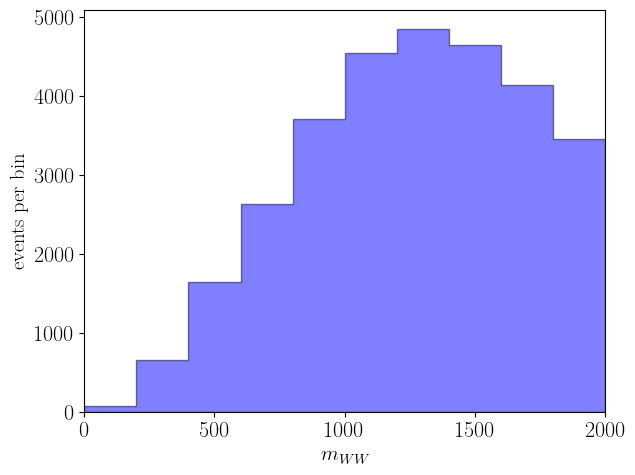

In [124]:
# in ATLAS bins
n, bins, _ =plt.hist(mWW_fat,bins=mWW_bins,range=(0,2000),label='non-linear axion', alpha=0.5,density=False,color = "blue", ec="k",histtype='stepfilled',log=False)
plt.xlim(0, 2000)
plt.tight_layout()
plt.xlabel(r'$m_{WW}$ ',fontsize=15)
plt.ylabel(r'events per bin',fontsize=15)
#plt.savefig("mgammagamma.pdf")
plt.show()

In [125]:
# calculate the efficiency as the number of events that fall into the bins
eps_fat = n.sum()/Ntot

In [126]:
eps_fat

0.30406

## Read in the digitised data and background from Figure 10f in the auxiliary material

In [127]:
#background 
background_fat = pd.read_csv('../MadGraph/ppWWjj1l/1leptonBG_mergedHP.csv', sep=';', nrows=10, header=0).values[:,1]

In [128]:
data_by_BG_fat = pd.read_csv('../MadGraph/ppWWjj1l/1leptonData_BGpoint_mergedHP.csv', sep=';', nrows=10, header=0).values[:,1]

In [129]:
unc_upper_by_BG_fat = pd.read_csv('../MadGraph/ppWWjj1l/1leptonData_BGupper_mergedHP.csv', sep=';', nrows=10, header=0).values[:,1]

In [130]:
unc_lower_by_BG_fat = pd.read_csv('../MadGraph/ppWWjj1l/1leptonData_BGlower_mergedHP.csv', sep=';', nrows=10, header=0).values[:,1]

In [131]:
len(background_fat)

10

In [132]:
len(data_by_BG_fat)

9

In [133]:
len(unc_upper_by_BG_fat)

9

In [134]:
len(unc_lower_by_BG_fat)

9

In [135]:
data_fat = np.multiply(data_by_BG_fat, background_fat[:-1])
unc_upper_fat = np.multiply(unc_upper_by_BG_fat, background_fat[:-1])
unc_lower_fat = np.multiply(unc_lower_by_BG_fat, background_fat[:-1])

In [136]:
data_fat=np.append(data_fat, 10.031245060382107)
unc_upper_fat=np.append(unc_upper_fat, 14.047390098114429)
unc_lower_fat=np.append(unc_lower_fat, 6.979182124229673)

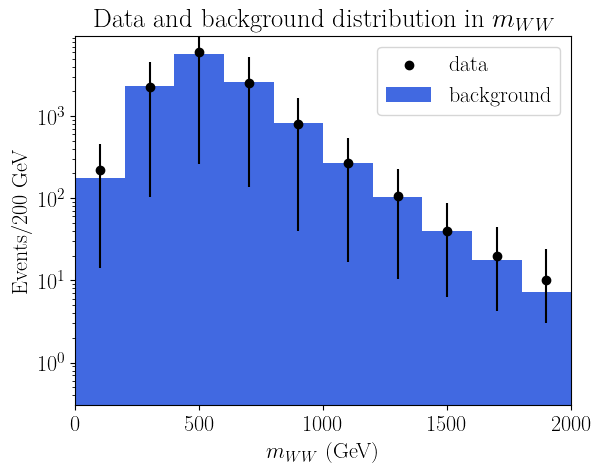

In [137]:
plt.bar(mWW_bins[:-1], background_fat, width=np.diff(mWW_bins), align='edge', alpha=1, color='royalblue',label='background')
plt.scatter(mWW_bin_center, data_fat, color='black', label='data')
plt.xlim(0,2000)
#plt.ylim(0,5)
plt.yscale("log")
plt.errorbar(mWW_bin_center, data_fat, [unc_lower_fat, unc_upper_fat], color='black', alpha=1,fmt='none')
plt.xlabel('$m_{WW}$ (GeV) ')
plt.ylabel(r'Events/200 GeV')
plt.title("Data and background distribution in $m_{WW}$")
plt.legend()

## Signal events in the right bins, normalised distribution 

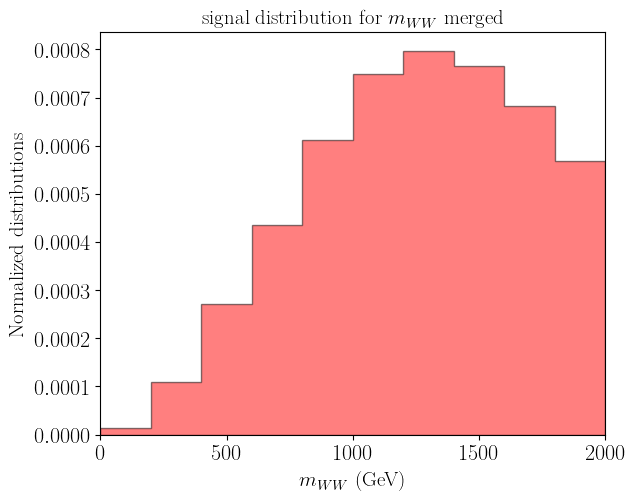

In [138]:
# histogram for NP signal (n = number of events per bin)
# density=True gives bin's raw count divided by the total number of counts and the bin width, i.e. density = counts / (sum(counts) * np.diff(bins))
n_signal_fat, bins, _ = plt.hist(mWW_fat,bins=mWW_bins,range=(0,2000),label='non-linear axion', alpha=0.5,density=True,color = "red", ec="k",histtype='stepfilled',log=False)
plt.xlim(0, 2000)
#plt.yscale("log")
plt.tight_layout()
plt.title(r'signal distribution for $m_{WW}$ merged ',fontsize=15)
plt.xlabel(r'$m_{WW}$ (GeV)',fontsize=15)
plt.ylabel(r'Normalized distributions',fontsize=15)
#plt.savefig("mHHdist.pdf")
plt.show()

In [139]:
(n_signal_fat*np.diff(mWW_bins)).sum()

0.9999999999999999

## Compare signal with data and background

In [140]:
# BR: factor of the branching ratios due to generating Z-> nu nu instead of Z-> jj
BR_Wlnu = 0.326
BR_Wjj = 0.6732

BR = BR_Wjj/BR_Wlnu

In [141]:
# rescale the MG5 signal events to compare with the data: N_events = n_signal * lumi * sigma * eps * BR
# eps = efficiency to the bin selection = number of events that fall in the ATLAS bins/ number of all events
# sigma in lhe file: total cross section including BR sigma in pb


# careful! the lumi is given in fb^-1 but the cross section from MadGraphin pb, which explains the additional factor of 1000.
lumi = 140

N_events_fat = n_signal_fat*lumi*sigma*1000*eps_fat*BR

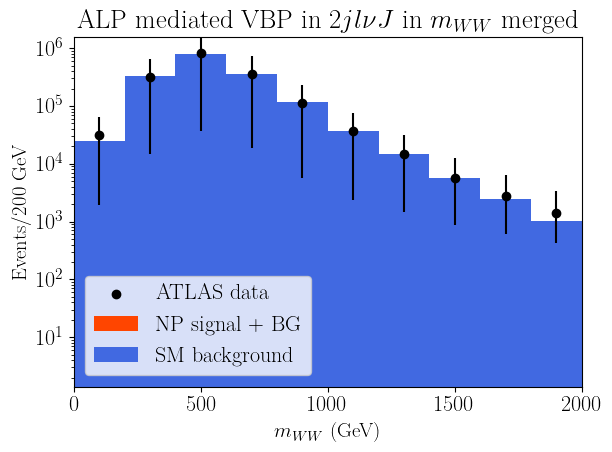

In [142]:
plt.bar(mWW_bins[:-1], background_fat*lumi+N_events_fat, width=np.diff(mWW_bins), align='edge', alpha=1, color='orangered', label='NP signal + BG')
plt.bar(mWW_bins[:-1], background_fat*lumi, width=np.diff(bins), align='edge', alpha=1, color='royalblue',label='SM background')
plt.xlim(0, 2000)
#plt.ylim(0,10000)
plt.yscale("log")
plt.xlabel('$m_{WW}$ (GeV)',fontsize=15)
plt.ylabel(r'Events/200 GeV', fontsize=15)
plt.errorbar(mWW_bin_center, data_fat*lumi, yerr=[unc_lower_fat*lumi, unc_upper_fat*lumi], color='black', alpha=1,fmt='none')
plt.scatter(mWW_bin_center, data_fat*lumi, color='black', label='ATLAS data')
plt.legend(loc=3)
plt.title(r" ALP mediated VBP in $2jl\nu J$ in $m_{WW}$ merged")
plt.tight_layout()
plt.savefig("/Users/esser/Documents/PROJECTS/ALPsPheno/ALP GLOBAL/github/ALP_GLOBAL/Figures/WWjj1l_merged.pdf")
plt.show()

### Output data to Mathematica

In [97]:
# calculate the mean error from the upper and lower end
data_unc_fat = (unc_upper_fat-unc_lower_fat)/2

In [95]:
# data
Mathematica_data = "{" + ",".join([f"{x:.4e}".replace('e', '*10^') for x in data_fat]) + "}" + ";"
print(Mathematica_data)

{2.2342*10^+02,2.2287*10^+03,5.9551*10^+03,2.5511*10^+03,8.0710*10^+02,2.6589*10^+02,1.0692*10^+02,4.0379*10^+01,1.9848*10^+01,1.0031*10^+01};


In [98]:
# data unc
Mathematica_data_unc = "{" + ",".join([f"{x:.4e}".replace('e', '*10^') for x in data_unc_fat]) + "}" ";"
print(Mathematica_data_unc)

{1.4687*10^+01,1.0633*10^+02,2.7439*10^+02,1.2290*10^+02,4.0026*10^+01,1.5903*10^+01,1.0255*10^+01,6.7247*10^+00,4.8899*10^+00,3.5341*10^+00};


In [99]:
# background
Mathematica_background = "{" + ",".join([f"{x:.4e}".replace('e', '*10^') for x in background_fat]) + "}" ";"
print(Mathematica_background)

{1.7578*10^+02,2.3275*10^+03,5.7291*10^+03,2.5790*10^+03,8.2648*10^+02,2.6718*10^+02,1.0351*10^+02,3.9980*10^+01,1.7598*10^+01,7.2786*10^+00};


In [100]:
# signal
N_signal_fat = n_signal_fat * lumi * sigma * 1000 * eps_fat * BR
Mathematica_signal = "{" + ",".join([f"{x:.4e}".replace('e', '*10^') for x in N_signal_fat]) + "}" ";"
print(Mathematica_signal)

{1.9658*10^-03,1.6193*10^-02,4.0520*10^-02,6.4921*10^-02,9.1337*10^-02,1.1185*10^-01,1.1910*10^-01,1.1439*10^-01,1.0188*10^-01,8.4997*10^-02};


In [101]:
# bin center
Mathematica_bin_center = "{" + ",".join(["{:.0f}".format(x) for x in mWW_bin_center]) + "}" ";"
print(Mathematica_bin_center)

{100,300,500,700,900,1100,1300,1500,1700,1900};
